In [2]:
import kagglehub
import pandas as  pd  
import os

# Download latest version
path = kagglehub.dataset_download("safaruzzamanshovo/graduate-admission-dataset")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "graduate_admission1.csv"))

100%|██████████| 10.1k/10.1k [00:00<00:00, 19.3MB/s]

Extracting files...
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/safaruzzamanshovo/graduate-admission-dataset/versions/1


In [3]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,GPA,Research,Chance of Admit
0,295,96,2,4.9,1.7,2.93,0,0.612
1,340,119,3,4.1,1.7,3.76,0,0.708
2,336,96,1,3.2,1.8,3.12,1,0.728
3,337,108,4,3.4,1.3,2.11,0,0.643
4,323,98,1,1.1,1.3,3.40,0,0.524


In [5]:
df.shape

(1000, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          1000 non-null   int64  
 1   TOEFL Score        1000 non-null   int64  
 2   University Rating  1000 non-null   int64  
 3   SOP                1000 non-null   float64
 4   LOR                1000 non-null   float64
 5   GPA                1000 non-null   float64
 6   Research           1000 non-null   int64  
 7   Chance of Admit    1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
x = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [9]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [13]:
y_train.shape

(800,)

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [16]:
x_train_scaled

array([[0.26      , 0.78571429, 0.        , ..., 0.05      , 0.26633166,
        0.        ],
       [0.9       , 0.25      , 0.        , ..., 0.225     , 0.32663317,
        1.        ],
       [0.94      , 0.53571429, 0.75      , ..., 0.05      , 0.84924623,
        0.        ],
       ...,
       [0.84      , 0.82142857, 0.        , ..., 0.3       , 0.21105528,
        1.        ],
       [0.32      , 0.53571429, 0.5       , ..., 0.15      , 0.58291457,
        1.        ],
       [1.        , 0.35714286, 0.        , ..., 0.4       , 0.41708543,
        1.        ]], shape=(800, 7))

In [17]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense


In [25]:
model = Sequential()

model.add(Dense(7, activation= 'relu', input_dim=7))
model.add(Dense(7, activation= 'relu'))
model.add(Dense(1, activation= 'linear'))

/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(loss = 'mean_squared_error', optimizer='Adam')

In [31]:
history = model.fit(x_train_scaled, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.3403e-04 - val_loss: 8.0880e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.3261e-04 - val_loss: 8.1498e-04
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.2397e-04 - val_loss: 9.8561e-04
Epoch 4/100
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0012

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.3262e-04 - val_loss: 9.6548e-04
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.2469e-04 - val_loss: 8.7991e-04
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.3163e-04 - val_loss: 8.6856e-04
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.3694e-04 - val_loss: 9.1119e-04
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.9712e-04 - val_loss: 8.0713e-04
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.2357e-04 - val_loss: 8.0280e-04
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.3792e-04 - val_loss: 8.8558e-04
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.4682e-04 - val_loss: 8.0862e-04
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.4619e-04 - val_loss: 8.0277e-04
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.4900e-04 - val_loss: 9.0502e-04
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.3221e-04 - val_l

In [32]:
y_pred = model.predict(x_test_scaled)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [33]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.8809913980405204

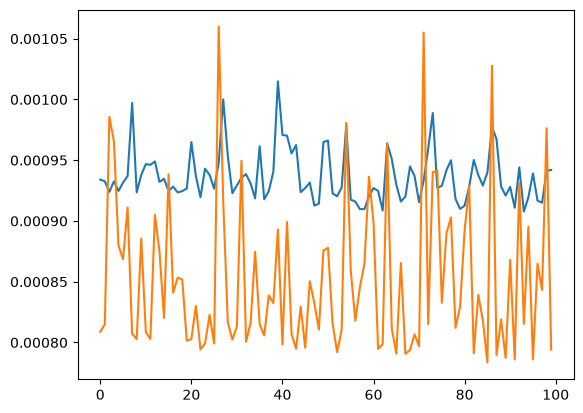

In [34]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
